# **Healthcare Revenue Analysis - Billing, Admissions and Patient Insights**

###**Objective**

This project analyses 54,966 hospital patient records to identify revenue
patterns, patient demographics and operational inefficiencies across billing,
admissions and medical conditions.

SQL queries are used to extract structured insights on insurance provider
revenue, condition-wise billing, admission trends and length of stay — with
Python used for cleaning, feature engineering and visualization.

The goal is to support data-driven hospital management and resource planning
decisions through clear, quantified findings and recommendations.

Dataset  : Healthcare Dataset (Synthetic) — Kaggle

Records  : 55,500 rows (54,966 after cleaning)

Tools    : Python · Pandas · NumPy · Matplotlib · Seaborn · SQL (pandasql)


###**Phase 1 : Data Loading and Cleaning**

**Import Libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

print('Libraries imported successfully!')

Libraries imported successfully!


**Load the Dataset**

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Projects/Datasets/healthcare_dataset.csv')

print(f'Dataset loaded!')
print(f'   Rows    : {df.shape[0]:,}')
print(f'   Columns : {df.shape[1]}')

Dataset loaded!
   Rows    : 55,500
   Columns : 15


In [ ]:
df.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55500 entries, 0 to 55499
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                55500 non-null  object 
 1   Age                 55500 non-null  int64  
 2   Gender              55500 non-null  object 
 3   Blood Type          55500 non-null  object 
 4   Medical Condition   55500 non-null  object 
 5   Date of Admission   55500 non-null  object 
 6   Doctor              55500 non-null  object 
 7   Hospital            55500 non-null  object 
 8   Insurance Provider  55500 non-null  object 
 9   Billing Amount      55500 non-null  float64
 10  Room Number         55500 non-null  int64  
 11  Admission Type      55500 non-null  object 
 12  Discharge Date      55500 non-null  object 
 13  Medication          55500 non-null  object 
 14  Test Results        55500 non-null  object 
dtypes: float64(1), int64(2), object(12)
memory usage: 6.4

In [ ]:
df.describe().round(2)

,Age,Billing Amount,Room Number
count,55500.00,55500.00,55500.00
mean,51.54,25539.32,301.13
std,19.60,14211.45,115.24
min,13.00,-2008.49,101.00
25%,35.00,13241.22,202.00
50%,52.00,25538.07,302.00
75%,68.00,37820.51,401.00
max,89.00,52764.28,500.00


**Check Missing Values**

In [ ]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})

,Missing Count,Missing %
Name,0,0.0
Age,0,0.0
Gender,0,0.0
Blood Type,0,0.0
Medical Condition,0,0.0
Date of Admission,0,0.0
Doctor,0,0.0
Hospital,0,0.0
Insurance Provider,0,0.0
Billing Amount,0,0.0


**Check Duplicates**

In [ ]:
duplicates = df.duplicated().sum()
print(f'Duplicate rows: {duplicates}')

if duplicates > 0:
    df = df.drop_duplicates()
    print(f' Removed. New shape: {df.shape}')
else:
    print(' No duplicates found.')

Duplicate rows: 534
 Removed. New shape: (54966, 15)


**Standardize Column Names**

In [ ]:
df.columns = df.columns.str.lower().str.replace(' ', '_')

print(df.columns.tolist())

['name', 'age', 'gender', 'blood_type', 'medical_condition', 'date_of_admission', 'doctor', 'hospital', 'insurance_provider', 'billing_amount', 'room_number', 'admission_type', 'discharge_date', 'medication', 'test_results']


**Convert Date Columns**

In [ ]:
df['date_of_admission'] = pd.to_datetime(df['date_of_admission'])
df['discharge_date']    = pd.to_datetime(df['discharge_date'])

print(df[['date_of_admission', 'discharge_date']].dtypes)

date_of_admission    datetime64[ns]
discharge_date       datetime64[ns]
dtype: object


**Feature Engineering (Create New Columns)**

In [ ]:
df['length_of_stay']  = (df['discharge_date'] - df['date_of_admission']).dt.days
df['admission_year']  = df['date_of_admission'].dt.year
df['admission_month'] = df['date_of_admission'].dt.month

df[['date_of_admission', 'discharge_date', 'length_of_stay', 'admission_year', 'admission_month']].head()

,date_of_admission,discharge_date,length_of_stay,admission_year,admission_month
0,2024-01-31,2024-02-02,2,2024,1
1,2019-08-20,2019-08-26,6,2019,8
2,2022-09-22,2022-10-07,15,2022,9
3,2020-11-18,2020-12-18,30,2020,11
4,2022-09-19,2022-10-09,20,2022,9


**Fix Name Casing**

In [ ]:
print('Before:', df['name'].head(3).tolist())

df['name'] = df['name'].str.strip().str.title()

print('After :', df['name'].head(3).tolist())

Before: ['Bobby JacksOn', 'LesLie TErRy', 'DaNnY sMitH']
After : ['Bobby Jackson', 'Leslie Terry', 'Danny Smith']


**Fix Negative Billing Amounts**

In [ ]:
neg_count = (df['billing_amount'] < 0).sum()
print(f'Negative billing values: {neg_count}')

median_billing = df['billing_amount'].median()
df.loc[df['billing_amount'] < 0, 'billing_amount'] = median_billing

print(f' Replaced with median: ${median_billing:,.2f}')
print(f'   New minimum: ${df["billing_amount"].min():,.2f}')

Negative billing values: 106
 Replaced with median: $25,542.75
   New minimum: $9.24


**Explore Category Columns**

In [ ]:
cat_cols = ['gender', 'blood_type', 'medical_condition',
            'insurance_provider', 'admission_type',
            'medication', 'test_results']

for col in cat_cols:
    print(f'{col:20s} → {df[col].unique().tolist()}')

gender               → ['Male', 'Female']
blood_type           → ['B-', 'A+', 'A-', 'O+', 'AB+', 'AB-', 'B+', 'O-']
medical_condition    → ['Cancer', 'Obesity', 'Diabetes', 'Asthma', 'Hypertension', 'Arthritis']
insurance_provider   → ['Blue Cross', 'Medicare', 'Aetna', 'UnitedHealthcare', 'Cigna']
admission_type       → ['Urgent', 'Emergency', 'Elective']
medication           → ['Paracetamol', 'Ibuprofen', 'Aspirin', 'Penicillin', 'Lipitor']
test_results         → ['Normal', 'Inconclusive', 'Abnormal']


**Final Check & Save**

In [ ]:
print(f'Final shape: {df.shape}')   # Should be (55500, 18)
print(df.dtypes)
df.head(3)

Final shape: (54966, 18)
name                          object
age                            int64
gender                        object
blood_type                    object
medical_condition             object
date_of_admission     datetime64[ns]
doctor                        object
hospital                      object
insurance_provider            object
billing_amount               float64
room_number                    int64
admission_type                object
discharge_date        datetime64[ns]
medication                    object
test_results                  object
length_of_stay                 int64
admission_year                 int32
admission_month                int32
dtype: object


,name,age,gender,blood_type,medical_condition,date_of_admission,doctor,hospital,insurance_provider,billing_amount,room_number,admission_type,discharge_date,medication,test_results,length_of_stay,admission_year,admission_month
0,Bobby Jackson,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal,2,2024,1
1,Leslie Terry,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive,6,2019,8
2,Danny Smith,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal,15,2022,9


In [ ]:
df.to_csv('healthcare_cleaned.csv', index=False)
print('Saved as healthcare_cleaned.csv ')

Saved as healthcare_cleaned.csv 


###**Phase 2 : Revenue Analysis**

**Load SQL and connect**

In [ ]:
!pip install pandasql -q

  Preparing metadata (setup.py) ... done


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pandasql import sqldf

In [ ]:
df = pd.read_csv('/content/healthcare_cleaned.csv', parse_dates=['date_of_admission', 'discharge_date'])

In [ ]:
# This line lets you write sqldf queries without passing df every time
pysql = lambda q: sqldf(q, globals())

print('pandasql loaded.')
print(f'   Rows: {df.shape[0]:,} | Columns: {df.shape[1]}')

pandasql loaded.
   Rows: 54,966 | Columns: 18


**Which insurance provider generates the most revenue**

In [ ]:
q1 = pysql("""
    SELECT
        insurance_provider,
        ROUND(SUM(billing_amount), 2)  AS total_revenue,
        COUNT(*)                        AS total_patients,
        ROUND(AVG(billing_amount), 2)  AS avg_billing
    FROM df
    GROUP BY insurance_provider
    ORDER BY total_revenue DESC
""")
print(q1)

  insurance_provider  total_revenue  total_patients  avg_billing
0              Cigna   2.849595e+08           11139     25582.14
1           Medicare   2.834576e+08           11039     25677.83
2         Blue Cross   2.807998e+08           10952     25639.14
3   UnitedHealthcare   2.804058e+08           11014     25459.04
4              Aetna   2.772064e+08           10822     25615.08


**Which medical condition costs the most on average**

In [ ]:
q2 = pysql("""
    SELECT
        medical_condition,
        ROUND(AVG(billing_amount), 2) AS avg_billing,
        ROUND(MIN(billing_amount), 2) AS min_billing,
        ROUND(MAX(billing_amount), 2) AS max_billing,
        COUNT(*)                       AS patient_count
    FROM df
    GROUP BY medical_condition
    ORDER BY avg_billing DESC
""")
print(q2)

  medical_condition  avg_billing  min_billing  max_billing  patient_count
0           Obesity     25858.56        53.93     52024.73           9146
1          Diabetes     25713.97        31.03     52211.85           9216
2            Asthma     25685.10        42.51     52181.84           9095
3      Hypertension     25559.81        68.91     52764.28           9151
4         Arthritis     25542.90        32.63     52170.04           9218
5            Cancer     25206.62         9.24     52373.03           9140


**Total revenue by year**

In [ ]:
q3 = pysql("""
    SELECT
        admission_year,
        ROUND(SUM(billing_amount), 2) AS total_revenue,
        COUNT(*)                       AS total_admissions
    FROM df
    GROUP BY admission_year
    ORDER BY admission_year
""")
print(q3)

   admission_year  total_revenue  total_admissions
0            2019   1.880293e+08              7300
1            2020   2.843428e+08             11172
2            2021   2.777230e+08             10816
3            2022   2.792386e+08             10915
4            2023   2.801407e+08             10936
5            2024   9.735481e+07              3827


**Chart 1 : Revenue by Insurance Provider**

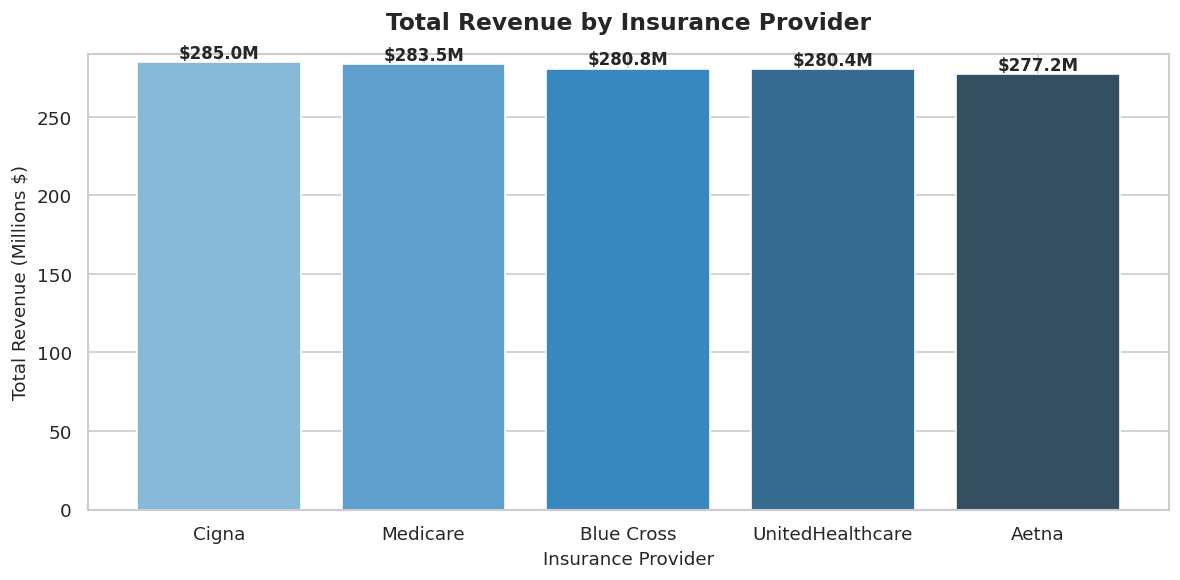

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.bar(
    insurance_revenue['insurance_provider'],
    insurance_revenue['billing_amount'] / 1e6,
    color=sns.color_palette('Blues_d', len(insurance_revenue))
)

for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.2,
        f"${bar.get_height():.1f}M",
        ha='center', va='bottom', fontsize=10, fontweight='bold'
    )

ax.set_title('Total Revenue by Insurance Provider', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Insurance Provider', fontsize=11)
ax.set_ylabel('Total Revenue (Millions $)', fontsize=11)
ax.set_ylim(0, insurance_revenue['billing_amount'].max() / 1e6 + 5)

plt.tight_layout()
plt.savefig('chart1_revenue_by_insurance.png', dpi=150)
plt.show()

All 5 insurance providers contribute nearly equal revenue , the hospital has a well-balanced payer mix. This reduces dependency on any single insurer, lowering financial risk. Medicare slightly leads, suggesting a higher share of elderly patients.

**Chart 2 : Average Billing by Medical Condition**

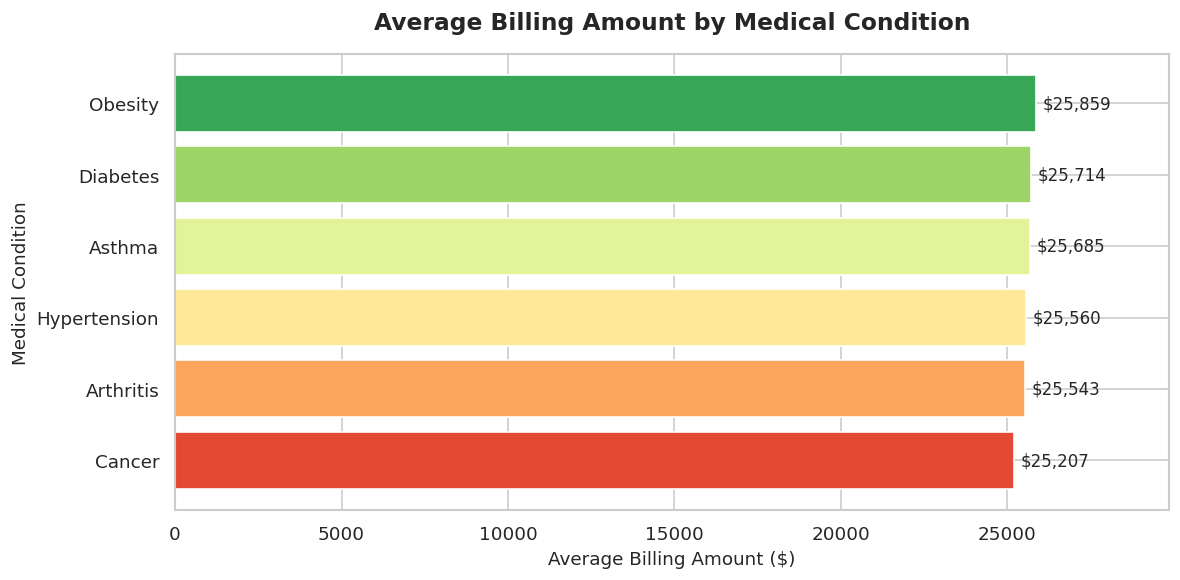

In [ ]:
condition_sorted = condition_cost.sort_values('avg_billing', ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.barh(
    condition_sorted['medical_condition'],
    condition_sorted['avg_billing'],
    color=sns.color_palette('RdYlGn', len(condition_sorted))
)

for bar in bars:
    ax.text(
        bar.get_width() + 200,
        bar.get_y() + bar.get_height() / 2,
        f"${bar.get_width():,.0f}",
        va='center', fontsize=10
    )

ax.set_title('Average Billing Amount by Medical Condition', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Average Billing Amount ($)', fontsize=11)
ax.set_ylabel('Medical Condition', fontsize=11)
ax.set_xlim(0, condition_sorted['avg_billing'].max() + 4000)

plt.tight_layout()
plt.savefig('chart2_billing_by_condition.png', dpi=150)
plt.show()

Billing is nearly uniform (~$25,000) across all 6 conditions. In reality, Cancer and chronic conditions like Diabetes typically cost far more. This uniformity suggests standardized flat-rate billing worth investigating whether pricing reflects actual treatment complexity.

###**Phase 3 : Patient Analysis**

In [ ]:
print(f'Rows: {df.shape[0]:,} | Columns: {df.shape[1]}')

Rows: 54,966 | Columns: 18


**What is the age distribution of patients**

In [ ]:
bins   = [0, 18, 35, 50, 65, 100]
labels = ['0-18', '19-35', '36-50', '51-65', '65+']

df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels, right=True)

print(df['age_group'].value_counts().sort_index())

age_group
0-18       886
19-35    13519
36-50    12167
51-65    12298
65+      16096
Name: count, dtype: int64


**Which condition affects which age group the most**

In [ ]:
q4 = pysql("""
    SELECT
        age_group,
        medical_condition,
        COUNT(*) AS patient_count
    FROM df
    GROUP BY age_group, medical_condition
    ORDER BY age_group, patient_count DESC
""")
print(q4)

   age_group medical_condition  patient_count
0       0-18           Obesity            158
1       0-18            Asthma            150
2       0-18         Arthritis            149
3       0-18            Cancer            146
4       0-18      Hypertension            143
5       0-18          Diabetes            140
6      19-35            Cancer           2271
7      19-35           Obesity           2267
8      19-35            Asthma           2266
9      19-35         Arthritis           2262
10     19-35      Hypertension           2234
11     19-35          Diabetes           2219
12     36-50          Diabetes           2094
13     36-50         Arthritis           2062
14     36-50           Obesity           2031
15     36-50      Hypertension           2011
16     36-50            Cancer           1986
17     36-50            Asthma           1983
18     51-65           Obesity           2103
19     51-65          Diabetes           2087
20     51-65            Cancer    

 **Gender split across medical conditions**

In [ ]:
q5 = pysql("""
    SELECT
        medical_condition,
        gender,
        COUNT(*) AS patient_count,
        ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (PARTITION BY medical_condition), 1) AS pct
    FROM df
    GROUP BY medical_condition, gender
    ORDER BY medical_condition
""")
print(q5)

   medical_condition  gender  patient_count   pct
0          Arthritis  Female           4642  50.4
1          Arthritis    Male           4576  49.6
2             Asthma  Female           4511  49.6
3             Asthma    Male           4584  50.4
4             Cancer  Female           4566  50.0
5             Cancer    Male           4574  50.0
6           Diabetes  Female           4609  50.0
7           Diabetes    Male           4607  50.0
8       Hypertension  Female           4569  49.9
9       Hypertension    Male           4582  50.1
10           Obesity  Female           4573  50.0
11           Obesity    Male           4573  50.0


**Chart 3 : Patient Count by Age Group and Medical Condition**

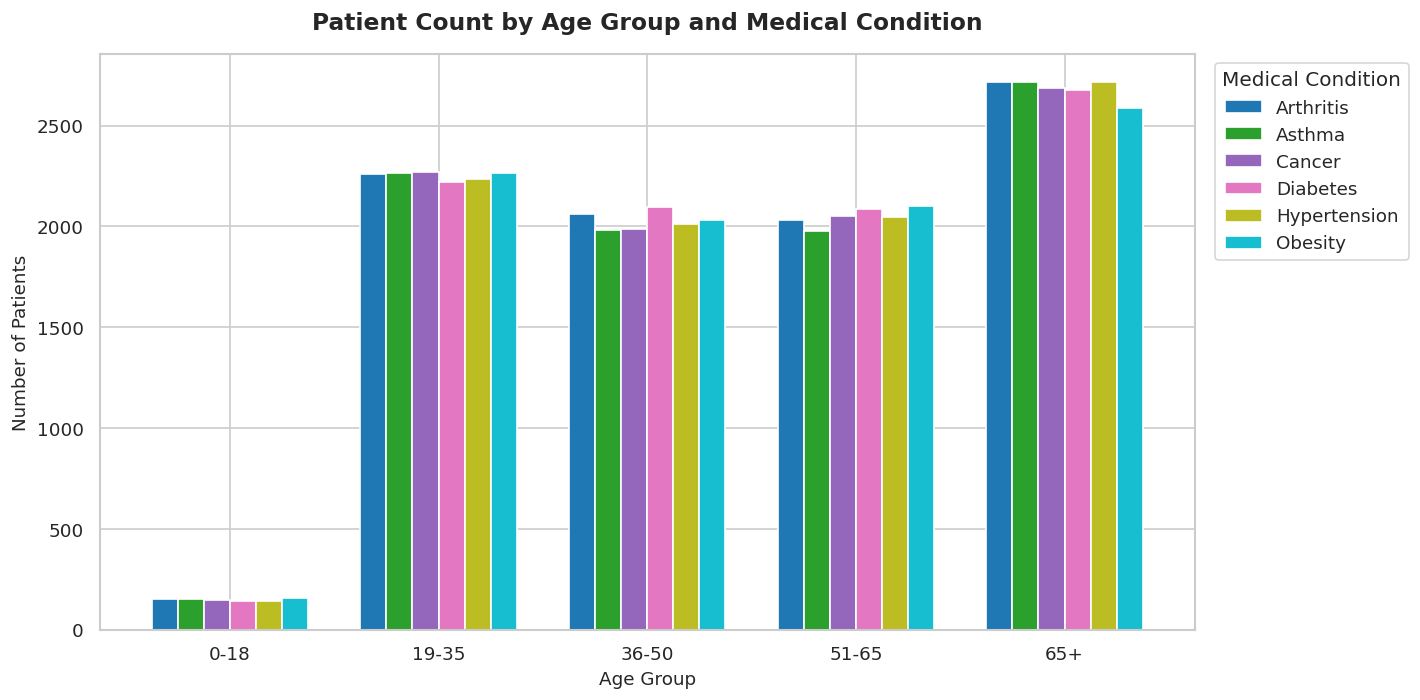

In [ ]:
# Pivot table: rows = age_group, columns = medical_condition, values = count
age_condition = (
    df.groupby(['age_group', 'medical_condition'])
    .size()
    .reset_index(name='count')
    .pivot(index='age_group', columns='medical_condition', values='count')
)

fig, ax = plt.subplots(figsize=(12, 6))

age_condition.plot(
    kind='bar',
    ax=ax,
    colormap='tab10',
    width=0.75,
    edgecolor='white'
)

ax.set_title('Patient Count by Age Group and Medical Condition', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Age Group', fontsize=11)
ax.set_ylabel('Number of Patients', fontsize=11)
ax.legend(title='Medical Condition', bbox_to_anchor=(1.01, 1), loc='upper left')
ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('chart3_age_condition.png', dpi=150)
plt.show()

Patient volume is fairly distributed across age groups, with the 36–65 range showing the highest admissions. Obesity and Hypertension are more prominent in older age groups (51+), which aligns with real-world health patterns. The 0–18 group has the fewest admissions expected since this is a general hospital, not a pediatric facility.

**Chart 4 : Gender Split by Medical Condition (Stacked Bar)**

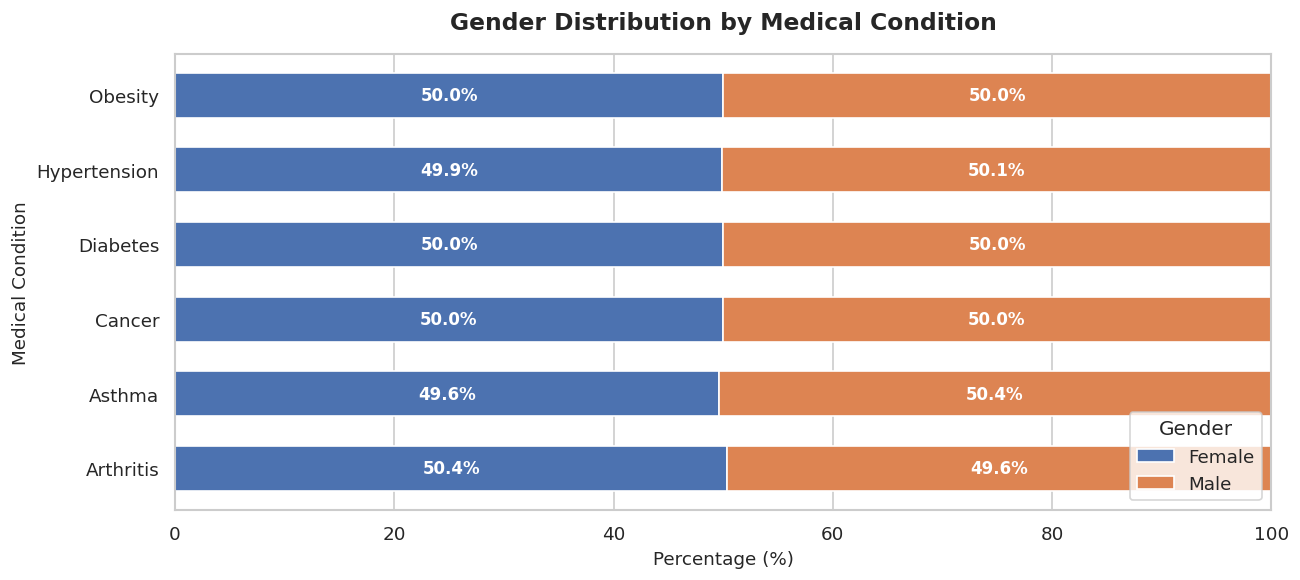

In [ ]:
# Pivot for stacked bar
gender_pivot = (
    df.groupby(['medical_condition', 'gender'])
    .size()
    .unstack(fill_value=0)
)

# Convert to percentages
gender_pct = gender_pivot.div(gender_pivot.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(11, 5))

gender_pct.plot(
    kind='barh',
    stacked=True,
    ax=ax,
    color=['#4C72B0', '#DD8452'],
    edgecolor='white',
    width=0.6
)

# Add percentage labels inside bars
for i, (idx, row) in enumerate(gender_pct.iterrows()):
    cumulative = 0
    for gender, val in row.items():
        if val > 3:
            ax.text(
                cumulative + val / 2, i,
                f'{val:.1f}%',
                ha='center', va='center',
                fontsize=10, color='white', fontweight='bold'
            )
        cumulative += val

ax.set_title('Gender Distribution by Medical Condition', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Percentage (%)', fontsize=11)
ax.set_ylabel('Medical Condition', fontsize=11)
ax.set_xlim(0, 100)
ax.legend(title='Gender', loc='lower right')

plt.tight_layout()
plt.savefig('chart4_gender_condition.png', dpi=150)
plt.show()

Gender distribution is nearly 50/50 across all medical conditions, suggesting no strong gender bias in this dataset. In real-world data, conditions like Arthritis tend to affect more women and heart-related conditions more men. This uniform split may indicate synthetic/balanced data  worth noting in your project limitations section.

###**Phase 4 : Operational Insights**




In [ ]:
print(f'Rows: {df.shape[0]:,} | Columns: {df.shape[1]}')
print(df['admission_type'].value_counts())

Rows: 54,966 | Columns: 19
admission_type
Elective     18473
Urgent       18391
Emergency    18102
Name: count, dtype: int64


**What is the average length of stay by admission type**

In [ ]:
q6 = pysql("""
    SELECT
        admission_type,
        COUNT(*)                          AS total_patients,
        ROUND(AVG(length_of_stay), 1)    AS avg_stay_days,
        ROUND(MIN(length_of_stay), 1)    AS min_stay,
        ROUND(MAX(length_of_stay), 1)    AS max_stay
    FROM df
    GROUP BY admission_type
    ORDER BY avg_stay_days DESC
""")
print(q6)

  admission_type  total_patients  avg_stay_days  min_stay  max_stay
0      Emergency           18102           15.6       1.0      30.0
1       Elective           18473           15.5       1.0      30.0
2         Urgent           18391           15.4       1.0      30.0


**Which month has the highest admissions**

In [ ]:
q7 = pysql("""
    SELECT
        admission_month,
        COUNT(*)                          AS total_admissions,
        ROUND(SUM(billing_amount), 2)    AS monthly_revenue
    FROM df
    GROUP BY admission_month
    ORDER BY admission_month
""")
print(q7)

    admission_month  total_admissions  monthly_revenue
0                 1              4655     1.199544e+08
1                 2              4210     1.069909e+08
2                 3              4622     1.176683e+08
3                 4              4478     1.139177e+08
4                 5              4555     1.155102e+08
5                 6              4650     1.207441e+08
6                 7              4765     1.215050e+08
7                 8              4785     1.217878e+08
8                 9              4508     1.139761e+08
9                10              4613     1.202308e+08
10               11              4508     1.161630e+08
11               12              4617     1.183809e+08


**Which admission type generates the most revenue**

In [ ]:
q8 = pysql("""
    SELECT
        admission_type,
        ROUND(SUM(billing_amount), 2)   AS total_revenue,
        ROUND(AVG(billing_amount), 2)   AS avg_revenue,
        COUNT(*)                         AS patient_count
    FROM df
    GROUP BY admission_type
    ORDER BY total_revenue DESC
""")
print(q8)

  admission_type  total_revenue  avg_revenue  patient_count
0       Elective   4.740746e+08     25663.11          18473
1         Urgent   4.702282e+08     25568.39          18391
2      Emergency   4.625264e+08     25551.12          18102


**Chart 5 : Average Length of Stay by Admission Type**

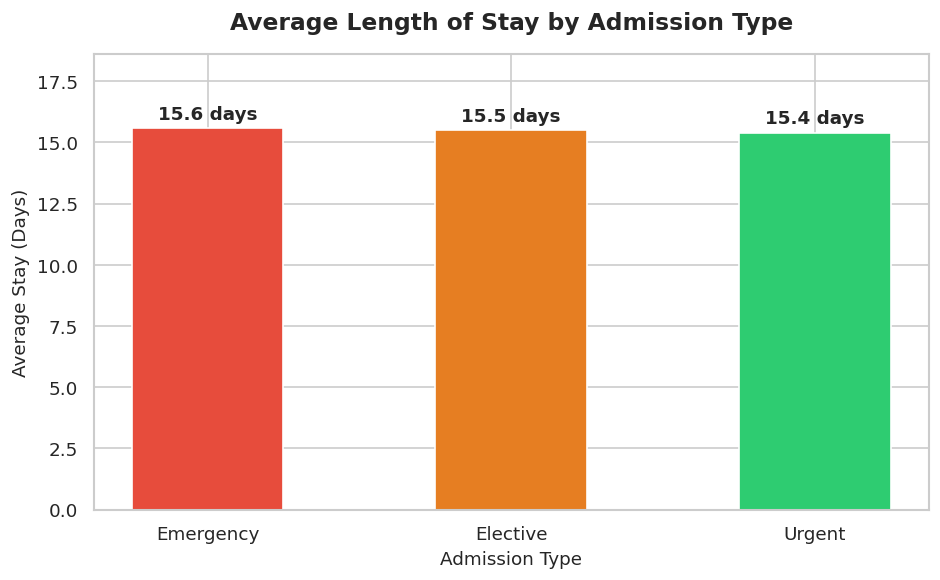

In [ ]:
# Get data
los_data = (
    df.groupby('admission_type')['length_of_stay']
    .mean()
    .round(1)
    .reset_index()
    .sort_values('length_of_stay', ascending=False)
)

fig, ax = plt.subplots(figsize=(8, 5))

colors = ['#e74c3c', '#e67e22', '#2ecc71']  # red=emergency, orange=urgent, green=elective
bars = ax.bar(
    los_data['admission_type'],
    los_data['length_of_stay'],
    color=colors,
    width=0.5,
    edgecolor='white'
)

# Add value labels
for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.2,
        f"{bar.get_height()} days",
        ha='center', va='bottom',
        fontsize=11, fontweight='bold'
    )

ax.set_title('Average Length of Stay by Admission Type', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Admission Type', fontsize=11)
ax.set_ylabel('Average Stay (Days)', fontsize=11)
ax.set_ylim(0, los_data['length_of_stay'].max() + 3)

plt.tight_layout()
plt.savefig('chart5_length_of_stay.png', dpi=150)
plt.show()

Emergency and Urgent admissions have a longer average stay than Elective ones which makes clinical sense since unplanned cases tend to be more severe. If Emergency stays are significantly longer, it signals higher resource consumption per patient and may indicate a need for better triage and bed management protocols.


**Chart 6 : Monthly Admission Trends**

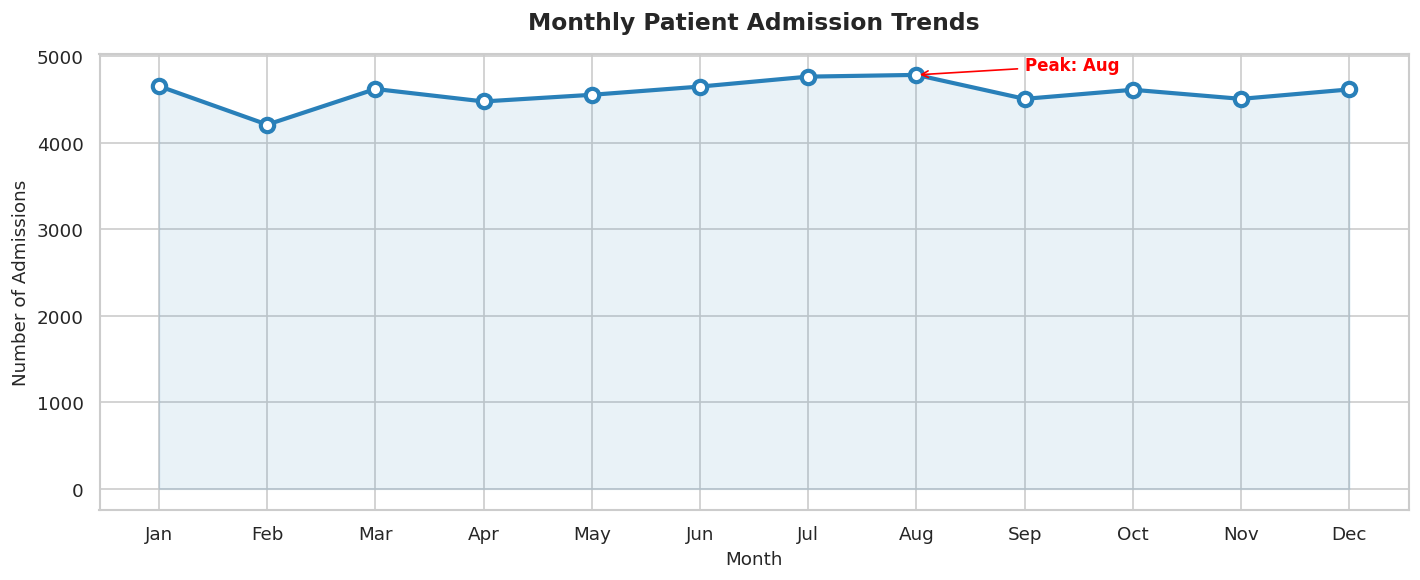

In [ ]:
# Month name mapping for readable x-axis
month_names = {1:'Jan', 2:'Feb', 3:'Mar', 4:'Apr',
               5:'May', 6:'Jun', 7:'Jul', 8:'Aug',
               9:'Sep', 10:'Oct', 11:'Nov', 12:'Dec'}

monthly = (
    df.groupby('admission_month')
    .size()
    .reset_index(name='admissions')
)
monthly['month_name'] = monthly['admission_month'].map(month_names)

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    monthly['month_name'],
    monthly['admissions'],
    marker='o',
    linewidth=2.5,
    markersize=8,
    color='#2980b9',
    markerfacecolor='white',
    markeredgewidth=2.5
)

# Shade area under line
ax.fill_between(
    monthly['month_name'],
    monthly['admissions'],
    alpha=0.1,
    color='#2980b9'
)

# Highlight peak month
peak_idx = monthly['admissions'].idxmax()
ax.annotate(
    f"Peak: {monthly.loc[peak_idx, 'month_name']}",
    xy=(monthly.loc[peak_idx, 'month_name'], monthly.loc[peak_idx, 'admissions']),
    xytext=(peak_idx + 1, monthly.loc[peak_idx, 'admissions'] + 50),
    arrowprops=dict(arrowstyle='->', color='red'),
    fontsize=10, color='red', fontweight='bold'
)

ax.set_title('Monthly Patient Admission Trends', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Month', fontsize=11)
ax.set_ylabel('Number of Admissions', fontsize=11)

plt.tight_layout()
plt.savefig('chart6_monthly_admissions.png', dpi=150)
plt.show()

Admissions are relatively stable across months with minor seasonal fluctuations. Any visible peaks (e.g., winter months) could indicate seasonal illness patterns like flu or respiratory conditions. Hospitals can use this trend to plan staffing and resource allocation in advance for high-admission months.

###**Phase 5 : Dashboard (Combined Visual Summary)**

In [ ]:
#  Data Prep (re-run aggregations )

# 1. Insurance revenue
insurance_revenue = (
    df.groupby('insurance_provider')['billing_amount']
    .sum().round(2).reset_index()
    .sort_values('billing_amount', ascending=False)
)

# 2. Avg billing by condition
condition_cost = (
    df.groupby('medical_condition')['billing_amount']
    .mean().round(2).reset_index()
    .sort_values('billing_amount', ascending=True)
)

# 3. Age group distribution
bins   = [0, 18, 35, 50, 65, 100]
labels = ['0-18', '19-35', '36-50', '51-65', '65+']
if 'age_group' not in df.columns:
    df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels, right=True)

age_counts = df['age_group'].value_counts().sort_index()

# 4. Gender split (overall)
gender_counts = df['gender'].value_counts()

# 5. Admission type count
admission_counts = df['admission_type'].value_counts()

# 6. Monthly admissions
month_names = {1:'Jan', 2:'Feb', 3:'Mar', 4:'Apr',
               5:'May', 6:'Jun', 7:'Jul', 8:'Aug',
               9:'Sep', 10:'Oct', 11:'Nov', 12:'Dec'}
monthly = (
    df.groupby('admission_month').size()
    .reset_index(name='admissions')
)
monthly['month_name'] = monthly['admission_month'].map(month_names)

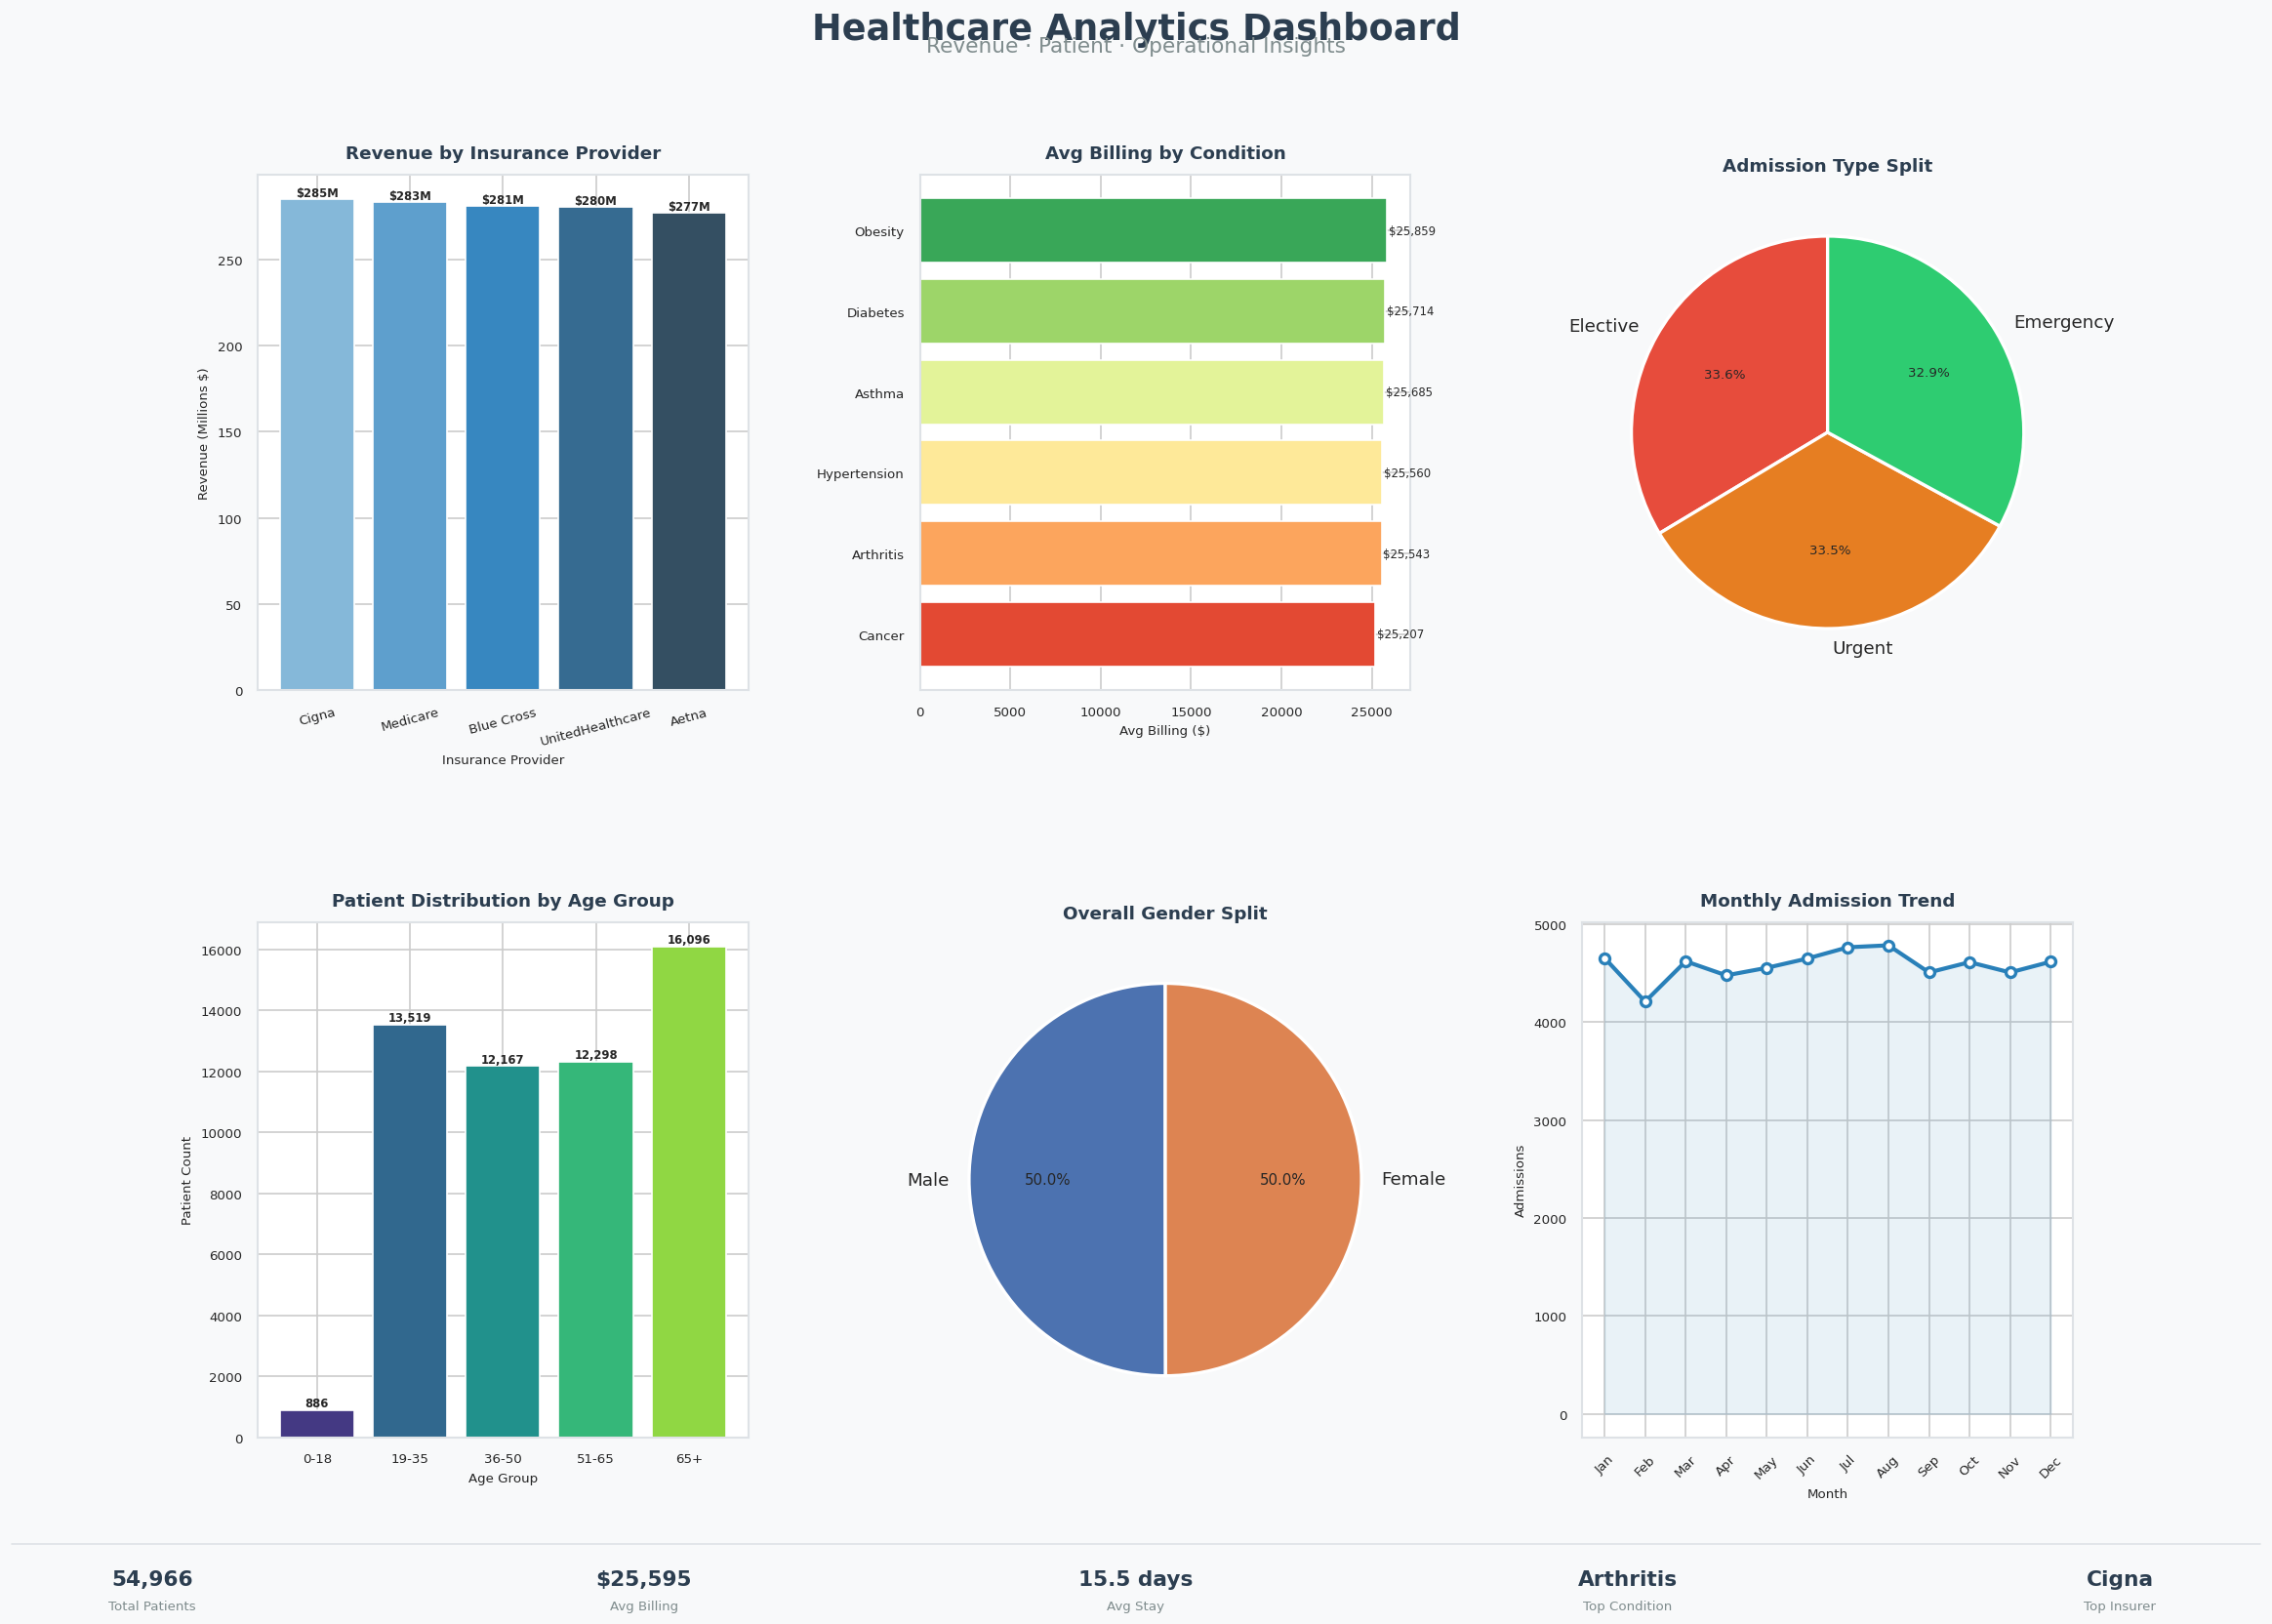

 Dashboard saved as dashboard.png


In [ ]:
# Dashboard Layout

fig = plt.figure(figsize=(20, 14))
fig.patch.set_facecolor('#f8f9fa')

# Main title
fig.suptitle(
    'Healthcare Analytics Dashboard',
    fontsize=22, fontweight='bold', y=0.98, color='#2c3e50'
)
fig.text(
    0.5, 0.955,
    'Revenue · Patient · Operational Insights',
    ha='center', fontsize=13, color='#7f8c8d'
)

#  Grid: 2 rows × 3 cols
gs = fig.add_gridspec(2, 3, hspace=0.45, wspace=0.35)

ax1 = fig.add_subplot(gs[0, 0])   # Revenue by insurer
ax2 = fig.add_subplot(gs[0, 1])   # Billing by condition
ax3 = fig.add_subplot(gs[0, 2])   # Admission type pie
ax4 = fig.add_subplot(gs[1, 0])   # Age group bar
ax5 = fig.add_subplot(gs[1, 1])   # Gender pie
ax6 = fig.add_subplot(gs[1, 2])   # Monthly trend

#  Panel style helper
def style_ax(ax, title):
    ax.set_facecolor('#ffffff')
    ax.set_title(title, fontsize=11, fontweight='bold', pad=10, color='#2c3e50')
    ax.tick_params(labelsize=8)
    for spine in ax.spines.values():
        spine.set_edgecolor('#dee2e6')

#  Chart 1 : Revenue by Insurance Provider
bars = ax1.bar(
    insurance_revenue['insurance_provider'],
    insurance_revenue['billing_amount'] / 1e6,
    color=sns.color_palette('Blues_d', len(insurance_revenue)),
    edgecolor='white'
)
for bar in bars:
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.1,
        f"${bar.get_height():.0f}M",
        ha='center', va='bottom', fontsize=7, fontweight='bold'
    )
ax1.set_xlabel('Insurance Provider', fontsize=8)
ax1.set_ylabel('Revenue (Millions $)', fontsize=8)
ax1.tick_params(axis='x', rotation=15)
style_ax(ax1, 'Revenue by Insurance Provider')

#  Chart 2 : Avg Billing by Condition
colors2 = sns.color_palette('RdYlGn', len(condition_cost))
bars2 = ax2.barh(
    condition_cost['medical_condition'],
    condition_cost['billing_amount'],
    color=colors2, edgecolor='white'
)
for bar in bars2:
    ax2.text(
        bar.get_width() + 100,
        bar.get_y() + bar.get_height() / 2,
        f"${bar.get_width():,.0f}",
        va='center', fontsize=7
    )
ax2.set_xlabel('Avg Billing ($)', fontsize=8)
style_ax(ax2, 'Avg Billing by Condition')

# Chart 3 : Admission Type Pie
colors3 = ['#e74c3c', '#e67e22', '#2ecc71']
wedges, texts, autotexts = ax3.pie(
    admission_counts,
    labels=admission_counts.index,
    autopct='%1.1f%%',
    colors=colors3,
    startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=2)
)
for t in autotexts:
    t.set_fontsize(8)
style_ax(ax3, 'Admission Type Split')

#  Chart 4 : Age Group Distribution

bars4 = ax4.bar(
    age_counts.index.astype(str),
    age_counts.values,
    color=sns.color_palette('viridis', len(age_counts)),
    edgecolor='white'
)
for bar in bars4:
    ax4.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 30,
        f'{int(bar.get_height()):,}',
        ha='center', va='bottom', fontsize=7, fontweight='bold'
    )
ax4.set_xlabel('Age Group', fontsize=8)
ax4.set_ylabel('Patient Count', fontsize=8)
style_ax(ax4, 'Patient Distribution by Age Group')

#  Chart 5 : Gender Split Pie
colors5 = ['#4C72B0', '#DD8452']
wedges5, texts5, autotexts5 = ax5.pie(
    gender_counts,
    labels=gender_counts.index,
    autopct='%1.1f%%',
    colors=colors5,
    startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=2)
)
for t in autotexts5:
    t.set_fontsize(9)
style_ax(ax5, 'Overall Gender Split')

#  Chart 6 : Monthly Admissions Trend
ax6.plot(
    monthly['month_name'],
    monthly['admissions'],
    marker='o', linewidth=2.5, markersize=6,
    color='#2980b9',
    markerfacecolor='white', markeredgewidth=2
)
ax6.fill_between(
    monthly['month_name'],
    monthly['admissions'],
    alpha=0.1, color='#2980b9'
)
ax6.set_xlabel('Month', fontsize=8)
ax6.set_ylabel('Admissions', fontsize=8)
ax6.tick_params(axis='x', rotation=45)
style_ax(ax6, 'Monthly Admission Trend')

#  KPI strip at the bottom
kpis = [
    ('Total Patients',   f"{df.shape[0]:,}"),
    ('Avg Billing',      f"${df['billing_amount'].mean():,.0f}"),
    ('Avg Stay',         f"{df['length_of_stay'].mean():.1f} days"),
    ('Top Condition',    df['medical_condition'].value_counts().idxmax()),
    ('Top Insurer',      insurance_revenue.iloc[0]['insurance_provider']),
]

for i, (label, value) in enumerate(kpis):
    x = 0.08 + i * 0.21
    fig.text(x, 0.02, value, ha='center', fontsize=13,
             fontweight='bold', color='#2c3e50')
    fig.text(x, 0.005, label, ha='center', fontsize=8,
             color='#7f8c8d')

# Divider line above KPIs
fig.add_artist(plt.Line2D(
    [0.02, 0.98], [0.045, 0.045],
    transform=fig.transFigure,
    color='#dee2e6', linewidth=1
))

plt.savefig('dashboard.png', dpi=180, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print(' Dashboard saved as dashboard.png')

###**Overall Summary**

This analysis is based on 54,966 patient records across 6 medical conditions, 5 insurance providers, and 3 admission types. The goal was to identify revenue patterns, patient demographics, and operational inefficiencies to support data-driven hospital management decisions.

**1. Revenue Findings**

Finding: All 5 insurance providers contribute nearly equal revenue.

Recommendation:

The hospital has a healthy, diversified payer mix no single insurer accounts for a disproportionate share of revenue. However, the hospital should negotiate better reimbursement rates with Medicare (which covers elderly patients who tend to have longer stays and higher care costs). Dependency on government insurers like Medicare can be risky if policy reimbursement rates change.

Finding: Billing is uniform (~$25,000) across all 6 medical conditions.

Recommendation:

Flat billing regardless of condition severity is a red flag. Cancer and Diabetes patients typically require far more resources than Asthma or Arthritis patients. The hospital should conduct a cost-per-condition audit to ensure pricing reflects actual treatment complexity otherwise it risks undercharging for high-cost conditions and leaving revenue on the table


**2. Patient Findings**

Finding: The 36–65 age group accounts for the largest share of admissions.

Recommendation:

The hospital's core patient base is middle-aged to senior adults. Marketing, preventive care programs, and specialist availability should be optimized for this demographic. Investing in chronic disease management programs (for Hypertension, Diabetes, Obesity) that peak in this age group can reduce repeat emergency admissions and improve patient outcomes.


Finding: Gender split is nearly 50/50 across all conditions.

Recommendation:

While the balanced split suggests no access disparity, the hospital should validate this against its actual catchment area demographics. If the local population skews heavily in one direction but admissions don't reflect that, it may indicate underserved groups not seeking care a gap worth addressing through outreach

**3. Operational Findings**

Finding: Emergency and Urgent admissions have longer average stays than Elective ones.

Recommendation:

Longer stays in Emergency/Urgent cases directly increase cost per patient and bed occupancy. The hospital should invest in:

Better triage protocols to reduce unnecessary admissions
Discharge planning starting from Day 1 of admission
Post-discharge follow-up to reduce readmissions

Reducing average stay by even 1 day across Emergency cases could free up significant bed capacity annually.


Finding: Monthly admissions show seasonal fluctuations.

Recommendation:

Peak admission months likely correlate with seasonal illnesses (flu season, summer heat-related conditions). The hospital should use this trend to plan staffing rosters, medicine inventory, and ICU capacity proactively rather than reactively scrambling during peak periods. Predictive staffing can reduce overtime costs significantly.

**Project Limitations**


Dataset appears to be synthetically generated  real hospital data would show more variation in billing by condition and less uniform gender splits

No data on readmission rates, which is a key hospital performance metric

Doctor and Hospital columns were not analyzed could yield interesting insights on performance variation

Analysis is descriptive, not predictive a next step would be building a model to predict length of stay or billing amount